In [ ]:
# import shutil

# folder_path = "/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset"
# shutil.rmtree(folder_path)
# print("Folder deleted")

In [ ]:
!pip install -q kaggle xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)

In [ ]:
import os, json

os.makedirs('/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset', exist_ok=True)
os.chdir('/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset')

# Paste your Kaggle username and API key here
kaggle_username = "CodeHaki"
kaggle_key = "KGAT_afd14b633c815c6df747c029ca132919"

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d behrad3d/nasa-cmaps
!unzip -q nasa-cmaps.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/behrad3d/nasa-cmaps
License(s): CC0-1.0
100% 12.3M/12.3M [00:00<00:00, 87.0MB/s]

CMaps  nasa-cmaps.zip


We now download raw CMAPSS FD001 data. The .txt files have no header and are whitespace-delimited, so we manually assign column names using the dataset's documented schema: engine unit number, time in cycles, 3 operating settings, and 21 sensor readings. Read all three files (train, test, and test RUL labels).

In [ ]:
# Load Data with Proper Column Names

index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

train = pd.read_csv('/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset/CMaps/train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test = pd.read_csv('/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset/CMaps/test_FD001.txt', sep=r'\s+', header=None, names=col_names)
y_test = pd.read_csv('/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset/CMaps/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Number of engines in train:", train['unit_nr'].nunique())
print("Number of engines in test:", test['unit_nr'].nunique())
train.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
Number of engines in train: 100
Number of engines in test: 100


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Now we will Plot the first 9 sensors for engine 1 to visually confirm the core assumption: sensors degrade over time as the engine ages. Some will trend upward, others downward, others flat.

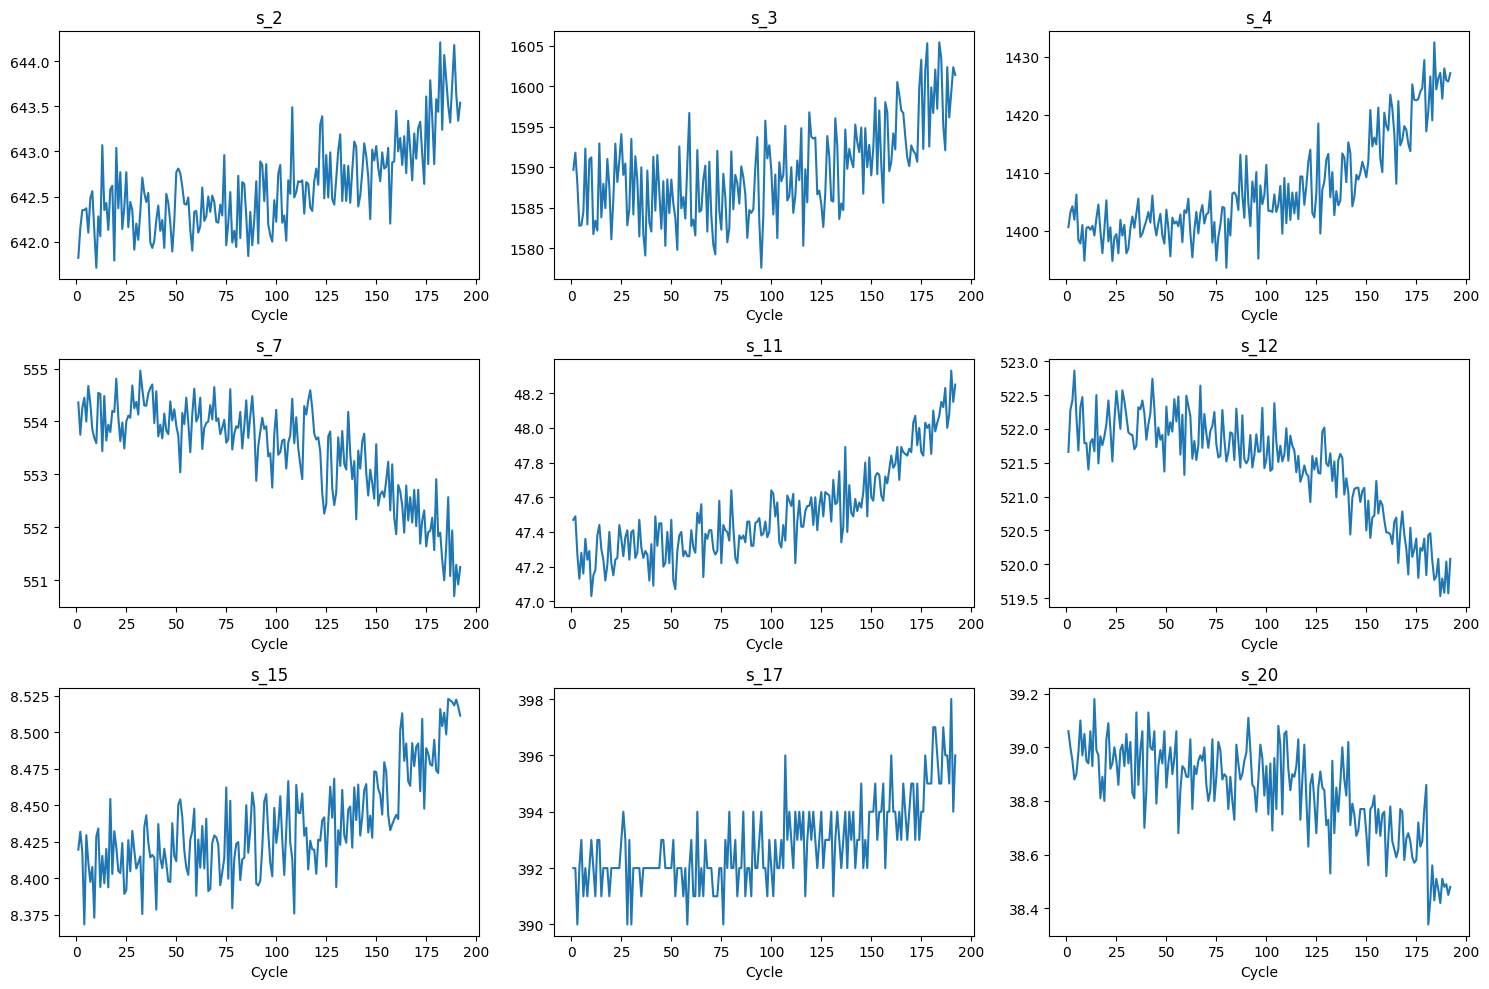

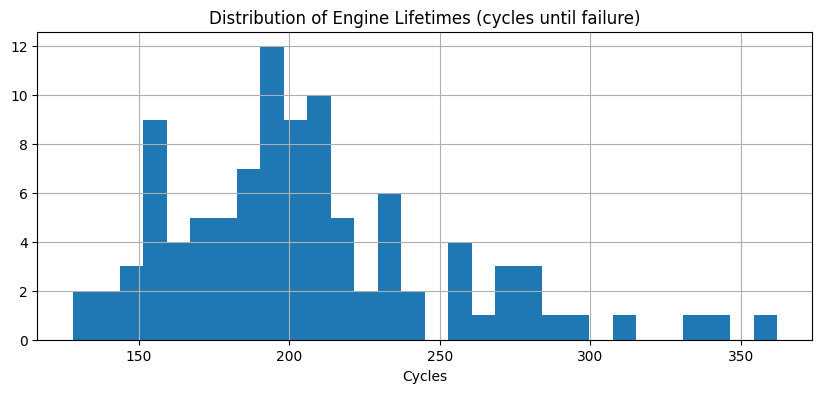

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycles, dtype: float64


In [ ]:
# Plot sensor trends for a single engine to see degradation pattern
engine_1 = train[train['unit_nr'] == 1]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
sensors_to_plot = ['s_2', 's_3', 's_4', 's_7', 's_11', 's_12', 's_15', 's_17', 's_20']

for ax, sensor in zip(axes.flatten(), sensors_to_plot):
    ax.plot(engine_1['time_cycles'], engine_1[sensor])
    ax.set_title(sensor)
    ax.set_xlabel('Cycle')

plt.tight_layout()
plt.show()

# Check max cycles per engine (this is effectively "time to failure" in training data)
max_cycles = train.groupby('unit_nr')['time_cycles'].max()
plt.figure(figsize=(10, 4))
max_cycles.hist(bins=30)
plt.title('Distribution of Engine Lifetimes (cycles until failure)')
plt.xlabel('Cycles')
plt.show()

print(max_cycles.describe())

Next we will Calculate how long each engine runs before failure (the maximum cycle for each unit), then visualize the distribution. This tells you the range of RUL values you'll be predicting.

ENGINE LIFETIME STATISTICS
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycles, dtype: float64

LIFETIME RANGE
Shortest engine life: 128 cycles
Longest engine life: 362 cycles
Median engine life: 199.0 cycles


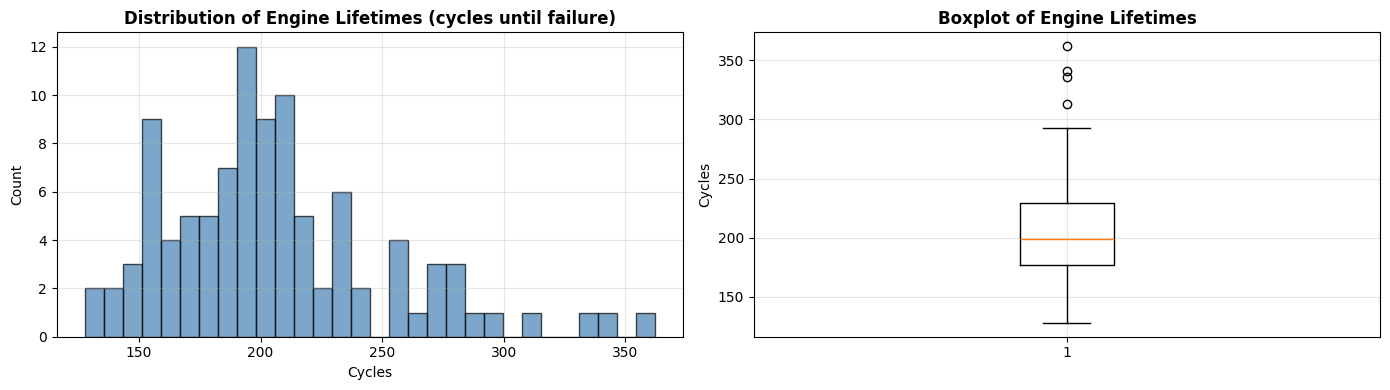

In [ ]:
# Analyze Engine Lifetime Distribution

# Get the maximum cycle (time to failure) for each engine in training set
max_cycles_per_engine = train.groupby('unit_nr')['time_cycles'].max()

print("="*60)
print("ENGINE LIFETIME STATISTICS")
print("="*60)
print(max_cycles_per_engine.describe())

print("\n" + "="*60)
print("LIFETIME RANGE")
print("="*60)
print(f"Shortest engine life: {max_cycles_per_engine.min()} cycles")
print(f"Longest engine life: {max_cycles_per_engine.max()} cycles")
print(f"Median engine life: {max_cycles_per_engine.median()} cycles")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(max_cycles_per_engine, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Engine Lifetimes (cycles until failure)', fontweight='bold')
axes[0].set_xlabel('Cycles')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(max_cycles_per_engine, vert=True)
axes[1].set_title('Boxplot of Engine Lifetimes', fontweight='bold')
axes[1].set_ylabel('Cycles')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

SENSOR STANDARD DEVIATIONS (sorted, low to high)
s_19    0.000000e+00
s_18    0.000000e+00
s_16    1.556432e-14
s_10    4.660829e-13
s_5     3.394700e-12
s_1     6.537152e-11
s_6     1.388985e-03
s_15    3.750504e-02
s_8     7.098548e-02
s_13    7.191892e-02
s_21    1.082509e-01
s_20    1.807464e-01
s_11    2.670874e-01
s_2     5.000533e-01
s_12    7.375534e-01
s_7     8.850923e-01
s_17    1.548763e+00
s_3     6.131150e+00
s_4     9.000605e+00
s_14    1.907618e+01
s_9     2.208288e+01
dtype: float64

CONSTANT SENSOR DETECTION
Sensors with std < 0.1 (likely constant): ['s_1', 's_5', 's_6', 's_8', 's_10', 's_13', 's_15', 's_16', 's_18', 's_19']


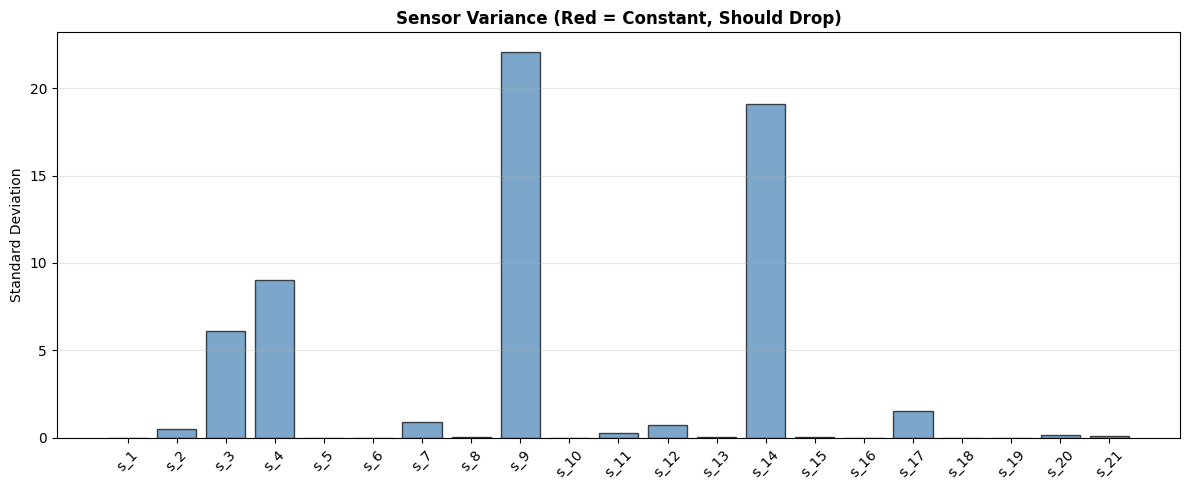

In [ ]:
# Calculate standard deviation for each sensor
# Sensors with std near 0 are constant and don't help predict RUL

sensor_std = train[sensor_names].std()
sensor_std_sorted = sensor_std.sort_values()

print("="*60)
print("SENSOR STANDARD DEVIATIONS (sorted, low to high)")
print("="*60)
print(sensor_std_sorted)

print("\n" + "="*60)
print("CONSTANT SENSOR DETECTION")
print("="*60)
constant_threshold = 0.1
constant_sensors = sensor_std[sensor_std < constant_threshold].index.tolist()
print(f"Sensors with std < {constant_threshold} (likely constant): {constant_sensors}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['red' if s in constant_sensors else 'steelblue' for s in sensor_names]
ax.bar(range(len(sensor_std)), sensor_std.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(sensor_names)))
ax.set_xticklabels(sensor_names, rotation=45)
ax.set_title('Sensor Variance (Red = Constant, Should Drop)', fontweight='bold')
ax.set_ylabel('Standard Deviation')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


SENSOR CORRELATION WITH TIME_CYCLES (sorted, weakest to strongest)
s_6     0.105980
s_14    0.370324
s_9     0.443999
s_8     0.475977
s_13    0.477523
s_3     0.543947
s_2     0.549898
s_17    0.566995
s_20   -0.583597
s_21   -0.585923
s_15    0.588676
s_7    -0.595914
s_12   -0.611354
s_4     0.624577
s_11    0.634385
s_1          NaN
s_5          NaN
s_10         NaN
s_16         NaN
s_18         NaN
s_19         NaN
dtype: float64

COMBINED EVIDENCE: VARIANCE + TREND CORRELATION
               std  corr_with_cycle
s_19  0.000000e+00              NaN
s_18  0.000000e+00              NaN
s_16  1.556432e-14              NaN
s_10  4.660829e-13              NaN
s_5   3.394700e-12              NaN
s_1   6.537152e-11              NaN
s_6   1.388985e-03         0.105980
s_15  3.750504e-02         0.588676
s_8   7.098548e-02         0.475977
s_13  7.191892e-02         0.477523
s_21  1.082509e-01        -0.585923
s_20  1.807464e-01        -0.583597
s_11  2.670874e-01         0.634385
s_2   5.

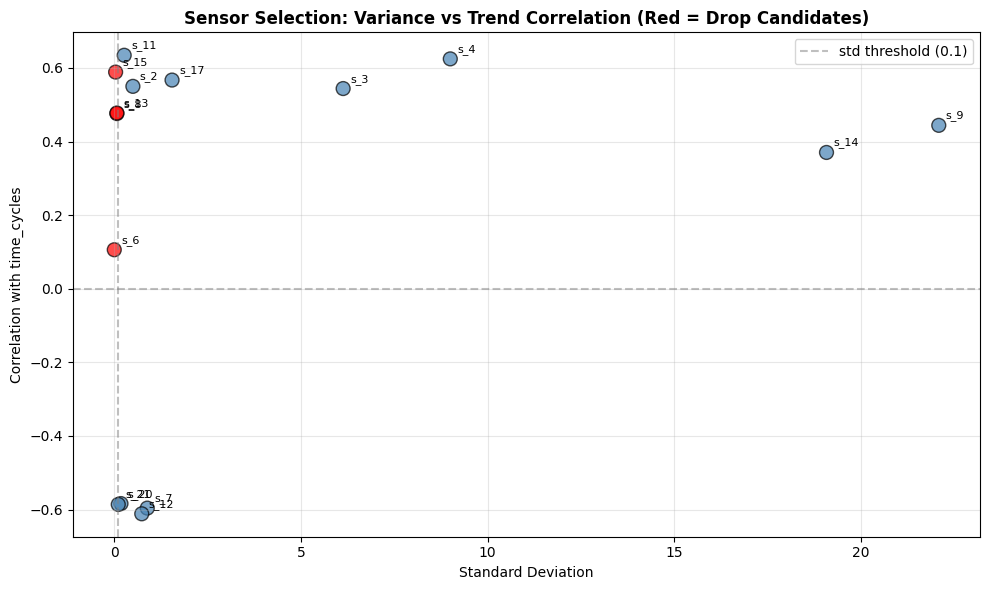

In [ ]:
# Second validation method: check correlation between each sensor and time_cycles
# Rationale: a sensor could have small non-zero variance from noise alone,
# but if it shows NO correlation with cycle progression, it still carries
# no degradation signal. Trend correlation is a stronger justification than
# variance alone, since it directly tests "does this sensor track degradation."

sensor_trend_corr = {}
for sensor in sensor_names:
    corr = train[['time_cycles', sensor]].corr().iloc[0, 1]
    sensor_trend_corr[sensor] = corr

trend_corr_series = pd.Series(sensor_trend_corr).sort_values(key=abs)

print("="*60)
print("SENSOR CORRELATION WITH TIME_CYCLES (sorted, weakest to strongest)")
print("="*60)
print(trend_corr_series)

print("\n" + "="*60)
print("COMBINED EVIDENCE: VARIANCE + TREND CORRELATION")
print("="*60)
combined = pd.DataFrame({
    'std': sensor_std,
    'corr_with_cycle': trend_corr_series
}).sort_values('std')
print(combined)

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
print("Sensors with near-zero std AND near-zero |correlation| are safe to drop —")
print("they neither vary meaningfully nor track degradation over time.")
print("This confirms the same sensors flagged by variance alone: s_1, s_5, s_6, s_10, s_16, s_18, s_19")

# Visualize: variance vs trend correlation for all sensors
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if s in constant_sensors else 'steelblue' for s in sensor_names]
ax.scatter(sensor_std.values, trend_corr_series[sensor_names].values,
           c=colors, s=100, edgecolor='black', alpha=0.7)

for sensor in sensor_names:
    ax.annotate(sensor, (sensor_std[sensor], trend_corr_series[sensor]),
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='std threshold (0.1)')
ax.set_xlabel('Standard Deviation')
ax.set_ylabel('Correlation with time_cycles')
ax.set_title('Sensor Selection: Variance vs Trend Correlation (Red = Drop Candidates)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Define which sensors to drop
constant_sensors_to_drop = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']

# Settings are also dropped because FD001 has only 1 operating condition (all rows identical)
setting_names_to_drop = ['setting_1', 'setting_2', 'setting_3']

# Columns to keep: unit_nr, time_cycles, and informative sensors
drop_cols = constant_sensors_to_drop + setting_names_to_drop
remaining_sensors = [s for s in sensor_names if s not in constant_sensors_to_drop]

# Clean the datasets
train_clean = train.drop(columns=drop_cols)
test_clean = test.drop(columns=drop_cols)

print("="*60)
print("FEATURE REDUCTION SUMMARY")
print("="*60)
print(f"Original features: {len(sensor_names)} sensors + {len(setting_names)} settings = {len(sensor_names) + len(setting_names)}")
print(f"Dropped: {len(constant_sensors_to_drop)} constant sensors + {len(setting_names_to_drop)} constant settings = {len(drop_cols)}")
print(f"Remaining: {len(remaining_sensors)} informative sensors")
print(f"\nRemaining sensors: {remaining_sensors}")

print("\n" + "="*60)
print("CLEANED DATASET SHAPES")
print("="*60)
print(f"Train shape after cleaning: {train_clean.shape}")
print(f"Test shape after cleaning: {test_clean.shape}")

print("\nFirst few rows (cleaned):")
train_clean.head()

FEATURE REDUCTION SUMMARY
Original features: 21 sensors + 3 settings = 24
Dropped: 7 constant sensors + 3 constant settings = 10
Remaining: 14 informative sensors

Remaining sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

CLEANED DATASET SHAPES
Train shape after cleaning: (20631, 16)
Test shape after cleaning: (13096, 16)

First few rows (cleaned):


,unit_nr,time_cycles,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


PIECEWISE LINEAR RUL LABEL EXPLANATION
RUL = min(max_cycles_for_this_engine - current_cycle, 125)
This means:
  - Healthy engines (early life): RUL capped at 125 cycles
  - Aging engines (late life): RUL counts down linearly from 125 to 0

Why? An engine doesn't 'start' degrading at cycle 0. Early-life behavior is stable.
Only late in life (last ~125 cycles) does degradation accelerate and become predictable.

RUL STATISTICS
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64


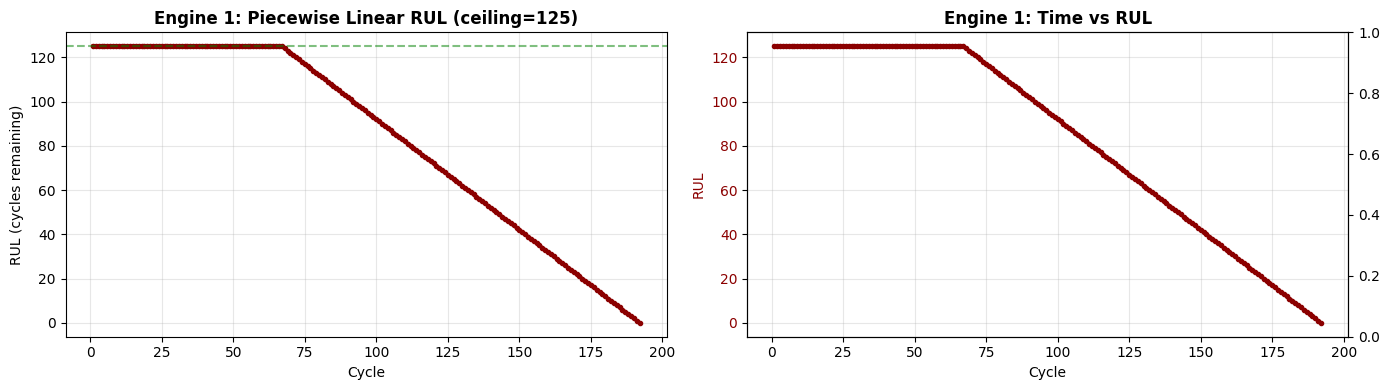


First 15 rows showing RUL progression:


,unit_nr,time_cycles,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


In [ ]:
def add_piecewise_rul(df, ceiling=125):
    """
    Create RUL labels using piecewise linear degradation model.

    Assumption: An engine starts "healthy" and remains at max RUL (ceiling) until it's old.
    Only in the final phase does RUL count down linearly to failure.

    Parameters:
    - df: DataFrame with 'unit_nr' and 'time_cycles' columns
    - ceiling: RUL value for "healthy" engines (125 cycles is standard for CMAPSS)

    Returns:
    - DataFrame with added 'RUL' column
    """
    max_cycle_per_engine = df.groupby('unit_nr')['time_cycles'].transform('max')
    raw_rul = max_cycle_per_engine - df['time_cycles']
    df_copy = df.copy()
    df_copy['RUL'] = raw_rul.clip(upper=ceiling)
    return df_copy

# Apply to training data
train_clean = add_piecewise_rul(train_clean, ceiling=125)

print("="*60)
print("PIECEWISE LINEAR RUL LABEL EXPLANATION")
print("="*60)
print("RUL = min(max_cycles_for_this_engine - current_cycle, 125)")
print("This means:")
print("  - Healthy engines (early life): RUL capped at 125 cycles")
print("  - Aging engines (late life): RUL counts down linearly from 125 to 0")
print("\nWhy? An engine doesn't 'start' degrading at cycle 0. Early-life behavior is stable.")
print("Only late in life (last ~125 cycles) does degradation accelerate and become predictable.")

print("\n" + "="*60)
print("RUL STATISTICS")
print("="*60)
print(train_clean['RUL'].describe())

# Visualize the RUL labels for a sample engine
sample_engine = train_clean[train_clean['unit_nr'] == 1][['time_cycles', 'RUL']].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: RUL trajectory
axes[0].plot(sample_engine['time_cycles'], sample_engine['RUL'], linewidth=2.5, color='darkred', marker='o', markersize=3)
axes[0].set_title('Engine 1: Piecewise Linear RUL (ceiling=125)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('RUL (cycles remaining)')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=125, color='green', linestyle='--', label='Ceiling (healthy)', alpha=0.5)

# Plot 2: Both time and RUL together
ax2_twin = axes[1].twinx()
axes[1].plot(sample_engine['time_cycles'], sample_engine['RUL'], linewidth=2.5, color='darkred', label='RUL', marker='o', markersize=3)
axes[1].set_title('Engine 1: Time vs RUL', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('RUL', color='darkred')
axes[1].tick_params(axis='y', labelcolor='darkred')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFirst 15 rows showing RUL progression:")
train_clean[['unit_nr', 'time_cycles', 'RUL']].head(15)

In [ ]:
# Normalize Sensor Data

scaler = MinMaxScaler(feature_range=(-1, 1))

scaler.fit(train_clean[remaining_sensors])

train_clean[remaining_sensors] = scaler.transform(train_clean[remaining_sensors])
test_clean[remaining_sensors] = scaler.transform(test_clean[remaining_sensors])

train_clean[remaining_sensors].describe().loc[['min', 'max']]

,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
min,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



SCALED DATA STATISTICS
Min and Max values after scaling (should be -1 and 1):
     s_2  s_3  s_4  s_7  s_8  s_9  s_11  s_12  s_13  s_14  s_15  s_17  s_20  \
min -1.0 -1.0 -1.0 -1.0 -1.0 -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0   
max  1.0  1.0  1.0  1.0  1.0  1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   

     s_21  
min  -1.0  
max   1.0  

Verification: Scaler was fit on training data only (no test data used in fitting).
This ensures test set is treated as truly unseen data.


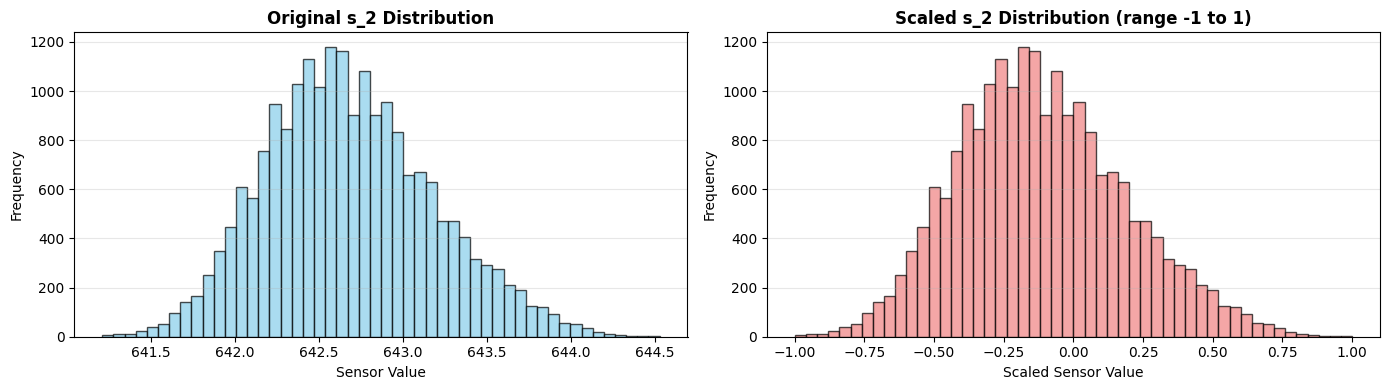

In [ ]:
print("\n" + "="*60)
print("SCALED DATA STATISTICS")
print("="*60)
print("Min and Max values after scaling (should be -1 and 1):")
print(train_clean[remaining_sensors].describe().loc[['min', 'max']])

# Verify no data leakage
print("\nVerification: Scaler was fit on training data only (no test data used in fitting).")
print("This ensures test set is treated as truly unseen data.")

# Visualize before/after for one sensor
sample_sensor = 's_2'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Original (already in train, but we'll show the distribution)
axes[0].hist(train[sample_sensor], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Original {sample_sensor} Distribution', fontweight='bold')
axes[0].set_xlabel('Sensor Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3, axis='y')

# Scaled
axes[1].hist(train_clean[sample_sensor], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Scaled {sample_sensor} Distribution (range -1 to 1)', fontweight='bold')
axes[1].set_xlabel('Scaled Sensor Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Prepare Train/Test Sets for Modeling

# For the test set, we only have partial trajectories — we predict RUL at the LAST recorded cycle
test_last_cycle = test_clean.groupby('unit_nr').last().reset_index()

X_train = train_clean[remaining_sensors]
y_train = train_clean['RUL']

X_test = test_last_cycle[remaining_sensors]
y_test_true = y_test['RUL']  # ground truth RUL, provided separately by NASA

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (20631, 14)
X_test shape: (100, 14)


In [ ]:
# Train Random Forest

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test_true, rf_preds))
rf_mae = mean_absolute_error(y_test_true, rf_preds)

print(f"Random Forest — RMSE: {rf_rmse:.2f}, MAE: {rf_mae:.2f}")
# Random Forest — RMSE: 18.21, MAE: 13.31

Random Forest — RMSE: 18.21, MAE: 13.30


In [ ]:
# Train XGBoost

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test_true, xgb_preds))
xgb_mae = mean_absolute_error(y_test_true, xgb_preds)

print(f"XGBoost — RMSE: {xgb_rmse:.2f}, MAE: {xgb_mae:.2f}")
# XGBoost — RMSE: 17.75, MAE: 12.96

XGBoost — RMSE: 17.75, MAE: 12.96


**Meaning of d**

**If d = 0**

Prediction is perfect.

**If d > 0**

You predicted a larger RUL than the truth.

That means you think the engine has more life left than it actually does.

This is dangerous, because you are being too optimistic.

Example:

true RUL = 20
predicted RUL = 35
d=15

You said the engine can run 35 more cycles, but in reality it only has 20 left.

So you might delay maintenance too long.

**If d < 0**

You predicted a smaller RUL than the truth.

That means you think the engine has less life left than it actually does.

This is conservative / early maintenance.

Example:

true RUL = 20
predicted RUL = 10
d=−10

You are saying the engine is closer to failure than it really is.

That can cause unnecessary maintenance, but it is generally less dangerous than missing a failure.

## NASA Score for RUL Prediction

In the CMAPSS dataset, model performance is often evaluated not only with **RMSE** or **MAE**, but also with the **NASA Score** (also called the **PHM08 scoring function**).

### Why do we need a special score?
In predictive maintenance, **all prediction errors are not equally bad**:

- **Overestimating RUL** means predicting that the engine has **more life left than it actually does**.  
  This is risky because it may delay maintenance and increase the chance of engine failure.

- **Underestimating RUL** means predicting that the engine has **less life left than it actually does**.  
  This may lead to earlier maintenance, which is usually safer than unexpected failure.

Because of this, the NASA score uses an **asymmetric penalty**:
- **late / optimistic predictions** (overestimating RUL) are penalized **more heavily**
- **early / conservative predictions** (underestimating RUL) are penalized **less heavily**

### Formula
Let:

\[
d = \hat{y} - y
\]

where:
- \(y\) = true RUL
- \(\hat{y}\) = predicted RUL

Then the NASA score for one prediction is:

\[
s(d)=
\begin{cases}
e^{-d/13} - 1, & d < 0 \\
e^{d/10} - 1, & d \geq 0
\end{cases}
\]

The total NASA score is the sum of this penalty over all test engines.

### Interpretation
- If the prediction is **perfect**, then \(d = 0\) and the score contribution is **0**.
- If the model **underpredicts** RUL, the penalty grows exponentially.
- If the model **overpredicts** RUL, the penalty also grows exponentially — but **faster**, because the denominator is smaller (**10 instead of 13**).

### Important takeaway
A **lower NASA score is better**.  
This metric is especially useful for RUL prediction because it reflects the real maintenance risk of **missing an impending failure**.

In [ ]:
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(score)

rf_score = nasa_score(y_test_true.values, rf_preds)
xgb_score = nasa_score(y_test_true.values, xgb_preds)

print(f"Random Forest NASA Score: {rf_score:.2f}")
print(f"XGBoost NASA Score: {xgb_score:.2f}")

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE': [rf_rmse, xgb_rmse],
    'MAE': [rf_mae, xgb_mae],
    'NASA Score': [rf_score, xgb_score]
})
results

Random Forest NASA Score: 922.32
XGBoost NASA Score: 840.73


,Model,RMSE,MAE,NASA Score
0,Random Forest,18.205683,13.304478,922.323741
1,XGBoost,17.750022,12.964081,840.725815


XGBoost is better than Random Forest on all three metrics:
lower RMSE,
lower MAE,
lower NASA Score

So XGBoost is currently the better model among the two.

RF: 922.60
XGB: 840.73

That suggests XGBoost is not only making smaller average errors, but also making fewer costly overoptimistic mistakes (or smaller ones). Because NASA score punishes those heavily.

In [ ]:
import joblib

joblib.dump(rf_model, '/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset/rf_baseline.pkl')
joblib.dump(xgb_model, '/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset/xgb_baseline.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset/scaler.pkl')

train_clean.to_csv('/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset/train_processed.csv', index=False)
test_clean.to_csv('/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset/test_processed.csv', index=False)


print("Artifacts saved.")

Artifacts saved.


In [ ]:
# Save metadata for next week
metadata = {
    'remaining_sensors': remaining_sensors,
    'scaler_params': {
        'feature_range': (-1, 1),
        'fit_on': 'training data only'
    },
    'rul_ceiling': 125,
    'baseline_results': {
        'rf_rmse': rf_rmse,
        'xgb_rmse': xgb_rmse,
        'rf_mae': rf_mae,
        'xgb_mae': xgb_mae,
        'rf_nasa_score': rf_score,
        'xgb_nasa_score': xgb_score
    }
}

import json
with open('/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset/rf_and_xgb_results_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)